In [ ]:


import os
import numpy as np
import tensorflow as tf
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import (
    VGG16, ResNet50, MobileNet, InceptionV3, EfficientNetB0
)
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# ----------------------------------
# PATHS
# ----------------------------------
BASE_DIR = os.getcwd()
TRAIN_DIR = os.path.join(BASE_DIR, "data", "train")
VAL_DIR = os.path.join(BASE_DIR, "data", "val")
TEST_DIR = os.path.join(BASE_DIR, "data", "test")

IMG_SIZE = (224,224)
BATCH_SIZE = 32
EPOCHS = 10


In [2]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = train_gen.num_classes
class_names = list(train_gen.class_indices.keys())


Found 6225 images belonging to 11 classes.
Found 1092 images belonging to 11 classes.
Found 3187 images belonging to 11 classes.


In [3]:
def build_cnn():
    model = Sequential([
        Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
        MaxPooling2D(2,2),

        Conv2D(64,(3,3),activation='relu'),
        MaxPooling2D(2,2),

        Conv2D(128,(3,3),activation='relu'),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(256,activation='relu'),
        Dropout(0.5),
        Dense(num_classes,activation='softmax')
    ])

    model.compile(
        optimizer=Adam(0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [4]:
def build_transfer_model(base_model_class):

    base_model = base_model_class(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )

    base_model.trainable = False

    model = Sequential([
        base_model,
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [5]:
models_dict = {
    "CNN": build_cnn(),
    "VGG16": build_transfer_model(VGG16),
    "ResNet50": build_transfer_model(ResNet50),
    "MobileNet": build_transfer_model(MobileNet),
    "InceptionV3": build_transfer_model(InceptionV3),
    "EfficientNetB0": build_transfer_model(EfficientNetB0)
}

results = []

best_acc = 0
best_model_name = None

for name, model in models_dict.items():

    print(f"\nTraining {name}...\n")

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS
    )

    loss, acc = model.evaluate(test_gen)

    results.append([name, acc])

    if acc > best_acc:
        best_acc = acc
        best_model_name = name
        model.save(f"models/best_model.h5")

results_df = pd.DataFrame(results, columns=["Model","Test Accuracy"])
print(results_df)


d:\capstone_project_5th\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

Training CNN...

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 408s 2s/step - accuracy: 0.3949 - loss: 1.7327 - val_accuracy: 0.6209 - val_loss: 1.2372
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 316s 2s/step - accuracy: 0.5788 - loss: 1.2333 - val_accuracy: 0.6813 - val_loss: 0.9903
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 320s 2s/step - accuracy: 0.6540 - loss: 1.0102 - val_accuracy: 0.8150 - val_loss: 0.7030
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.7163 - loss: 0.8527 - val_accuracy: 0.8114 - val_loss: 0.6541
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 326s 2s/step - accuracy: 0.7589 - loss: 0.7338 - val_accuracy: 0.8434 - val_loss: 0.5385
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - accuracy: 0.7791 - loss: 0


Training VGG16...

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 2283s 12s/step - accuracy: 0.6013 - loss: 1.2191 - val_accuracy: 0.8855 - val_loss: 0.5427
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 1899s 10s/step - accuracy: 0.8384 - loss: 0.5635 - val_accuracy: 0.9258 - val_loss: 0.3205
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 1961s 10s/step - accuracy: 0.8914 - loss: 0.3852 - val_accuracy: 0.9579 - val_loss: 0.2129
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 4486s 23s/step - accuracy: 0.9176 - loss: 0.3004 - val_accuracy: 0.9679 - val_loss: 0.1695
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 1816s 9s/step - accuracy: 0.9388 - loss: 0.2377 - val_accuracy: 0.9762 - val_loss: 0.1306
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 1811s 9s/step - accuracy: 0.9467 - loss: 0.2013 - val_accuracy: 0.9771 - val_loss: 0.1095
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 1812s 9s/step - accuracy: 0.9561 - loss: 0.1624 - val_accuracy: 0.9789 - val_loss: 0.0924
Epoch 8/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 1864s 10s/step - accuracy:


Training ResNet50...

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 708s 4s/step - accuracy: 0.1637 - loss: 2.3562 - val_accuracy: 0.1859 - val_loss: 2.2176
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 682s 3s/step - accuracy: 0.1854 - loss: 2.2505 - val_accuracy: 0.1832 - val_loss: 2.1391
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 636s 3s/step - accuracy: 0.1929 - loss: 2.2070 - val_accuracy: 0.2024 - val_loss: 2.1550
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 667s 3s/step - accuracy: 0.1905 - loss: 2.1960 - val_accuracy: 0.1877 - val_loss: 2.1318
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 706s 4s/step - accuracy: 0.2032 - loss: 2.1466 - val_accuracy: 0.2344 - val_loss: 2.0491
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 744s 4s/step - accuracy: 0.2058 - loss: 2.1327 - val_accuracy: 0.2610 - val_loss: 2.0302
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 656s 3s/step - accuracy: 0.2076 - loss: 2.1143 - val_accuracy: 0.2262 - val_loss: 1.9920
Epoch 8/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 597s 3s/step - accuracy: 0.2369 - 


Training InceptionV3...

Epoch 1/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 421s 2s/step - accuracy: 0.7484 - loss: 0.8466 - val_accuracy: 0.9405 - val_loss: 0.2059
Epoch 2/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 405s 2s/step - accuracy: 0.8824 - loss: 0.3508 - val_accuracy: 0.9496 - val_loss: 0.1375
Epoch 3/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 400s 2s/step - accuracy: 0.9107 - loss: 0.2693 - val_accuracy: 0.9634 - val_loss: 0.1129
Epoch 4/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 403s 2s/step - accuracy: 0.9200 - loss: 0.2304 - val_accuracy: 0.9661 - val_loss: 0.0859
Epoch 5/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 408s 2s/step - accuracy: 0.9288 - loss: 0.2084 - val_accuracy: 0.9780 - val_loss: 0.0769
Epoch 6/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 410s 2s/step - accuracy: 0.9441 - loss: 0.1744 - val_accuracy: 0.9789 - val_loss: 0.0739
Epoch 7/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 408s 2s/step - accuracy: 0.9491 - loss: 0.1515 - val_accuracy: 0.9753 - val_loss: 0.0917
Epoch 8/10
195/195 ━━━━━━━━━━━━━━━━━━━━ 411s 2s/step - accuracy: 0.9452

In [6]:
best_model = tf.keras.models.load_model("models/best_model.h5")

pred = best_model.predict(test_gen)
y_pred = np.argmax(pred, axis=1)
y_true = test_gen.classes
  
print(classification_report(y_true, y_pred, target_names=class_names))
print(confusion_matrix(y_true, y_pred))


100/100 ━━━━━━━━━━━━━━━━━━━━ 95s 943ms/step
                                  precision    recall  f1-score   support

                     animal fish       0.99      1.00      0.99       520
                animal fish bass       1.00      0.54      0.70        13
   fish sea_food black_sea_sprat       1.00      1.00      1.00       298
   fish sea_food gilt_head_bream       1.00      0.99      0.99       305
   fish sea_food hourse_mackerel       1.00      1.00      1.00       286
        fish sea_food red_mullet       1.00      0.99      0.99       291
     fish sea_food red_sea_bream       0.99      1.00      1.00       273
          fish sea_food sea_bass       0.99      1.00      1.00       327
            fish sea_food shrimp       1.00      1.00      1.00       289
fish sea_food striped_red_mullet       0.99      1.00      0.99       293
             fish sea_food trout       1.00      1.00      1.00       292

                        accuracy                           1.00   

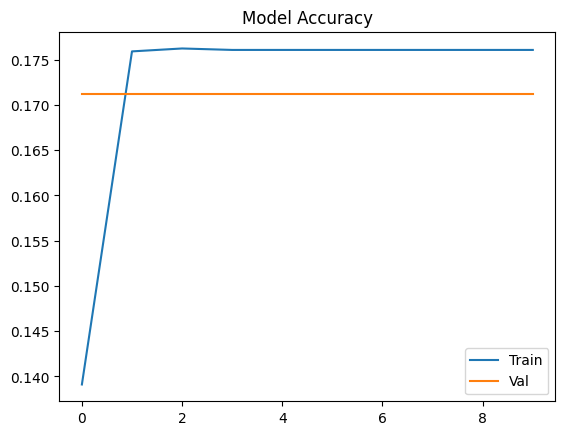

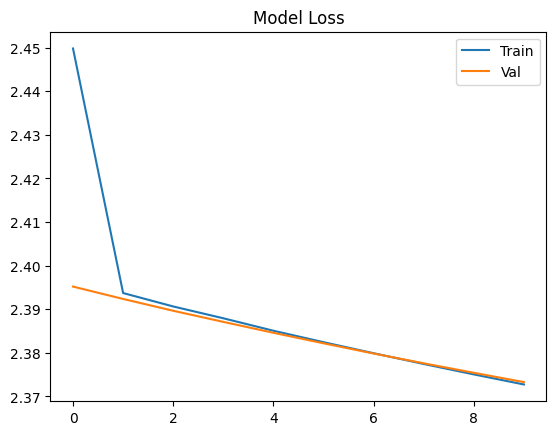

In [7]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(["Train","Val"])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.legend(["Train","Val"])
plt.show()
